# Backscatter mosaicking with knightswhosaydb

At it's most basic, this package can be used to create a backscatter mosaic from raw multibeam echosounder data. Currently supported data formats are listed on the [repository page](https://github.com/benjaminmisiuk/knightswhosaydb).

### KMALL
First we will use the ```mosaic()``` function to create a backscatter mosaic from Kongsberg KMALL files that are stored in a single directory. The function automatically applies angular varying gain (AVG) to compensate the backscatter for the angle of incidence.

In [1]:
from knightswhosaydb import mosaic

mosaic(
    dir_path='../data/KMALL/', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic.tif', #output mosaic
    crs='EPSG:32622' #coordinate reference system of raw data
)

Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic.tif


<br>
Here is an image of the mosaic visualized using external software.

<br>

<img src="images/Mosaic.png" style="height: 500px; width: auto;" />

These data are from a multifrequency MBES survey. Data were collected at 200, 400, and 600 kHz. We can isolate any one of these frequencies. Additionally, if we have another raster from the area (e.g., bathymetry), we can use that as a template for both resolution and coordinate reference. This is recommended for simplicity and accuracy in many cases. Here we have a 2 m bathymetric grid to use as the template.

In [7]:
mosaic(
    dir_path='../data/KMALL', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic_200.tif', #output mosaic
    frequency=200, #frequency to isolate
    template_path='../data/GIS/bathy_2m.tif' #coordinate reference system of raw data
)

Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200.tif


<img src="images/Mosaic_200.png" style="height: 500px; width: auto;" />

### Filtering
The knightswhosaydb package contains some basic filtering functionality that operates at the sounding level, not on pixels. Two basic "quantile filters" have been implemented that remove outliers by calculating moving window quantile values and removing soundings outside of the designated range (e.g., the 99th percentile).

The first is an along-track quantile filter, which operates on each MBES beam independently. This filter calculates the bottom and top qth percentiles in a moving window that is ```w``` soundings long. ```w``` is the length of the AVG window, which can be specified by the user. By default the filter uses 1 and 99th percentiles, but these can be adjusted. Both the values of backscatter and depth are considered in this filter. Note: quantile filters are aggressive. **They will ALWAYS remove data at the bottom and top quantiles.**

In [14]:
mosaic(
    dir_path='../data/KMALL', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic_200_alongfilter.tif', #output mosaic
    frequency=200, #frequency to isolate
    template_path='../data/GIS/bathy_2m.tif', #coordinate reference system of raw data
    w=400, #window length for AVG and along-track filter, defaults to 300
    filter_along=True #turn on the filter
)

Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200_alongfilter.tif


<img src="images/Mosaic_200_alongfilter.png" style="height: 500px; width: auto;" />

The second filter is across-track. It operates across the sounding swath by looking at the values between different beams, and is implemented after AVG has been performed. This effectively rejects soundings that are at the extreme ends of backscatter for a given ping, after angular normalization.

We can run both filters simultaneously, and control their aggressiveness by moving the quantiles further apart.

In [15]:
mosaic(
    dir_path='../data/KMALL', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic_200_alongacrossfilter.tif', #output mosaic
    frequency=200, #frequency to isolate
    template_path='../data/GIS/bathy_2m.tif', #coordinate reference system of raw data
    w=400, #window length for AVG and along-track filter, defaults to 300
    filter_along=True, #along-track filter
    filter_across=True, #across-track filter
    q_along=0.005, #quantile for along-track filter
    q_across=0.005 #quantile for across-track filter
)

Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200_alongacrossfilter.tif


<img src="images/Mosaic_200_alongacrossfilter.png" style="height: 500px; width: auto;" />

### Multifrequency
We can put process multiple frequencies using custom processing parameters and view the result.

In [16]:
#200 kHz
mosaic(
    dir_path='../data/KMALL', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic_200_multi.tif', #output mosaic
    frequency=200, #frequency to isolate
    crs='EPSG:32622', #coordinate reference system of raw data
    res=1, #output mosaic resolution
    w=400, #window length for AVG and along-track filter, defaults to 300
    filter_across=True, #across-track filter
)

#400 kHz
mosaic(
    dir_path='../data/KMALL', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic_400_multi.tif', #output mosaic
    frequency=400, #frequency to isolate
    crs='EPSG:32622', #coordinate reference system of raw data
    res=1, #output mosaic resolution
    w=400, #window length for AVG and along-track filter, defaults to 300
    filter_across=True, #across-track filter
)

#600 kHz
mosaic(
    dir_path='../data/KMALL', #raw data location
    format='kmall', #raw data format
    mosaic_path='../scratch/Mosaic_600_multi.tif', #output mosaic
    frequency=600, #frequency to isolate
    crs='EPSG:32622', #coordinate reference system of raw data
    res=1, #output mosaic resolution
    w=400, #window length for AVG and along-track filter, defaults to 300
    filter_across=True, #across-track filter
    q_across=0.05 #use a more aggressive filter for 600 kHz
)

Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200_multi.tif
Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_400_multi.tif
Found 10 files


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_600_multi.tif


<img src="images/Mosaic_multi.png" style="height: 500px; width: auto;" />

### FMGT
This package is not designed for bathymetric data processing and cleaning, and there is no plan to add that functionality. However, it is possible to use this package in conjunction with other software that can perform data cleaning.

One workflow is to load raw multibeam data into QPS software in order to apply cleaning and corrections,
then to export the soundings in order to mosaic with knightswhosaydb. This is useful for users who would like to use different mosaicking methods, or who would like to develop their own methods after first cleaning the data.

For this example, the raw data have been processed in QPS Qimera, including the application of vesel offsets, tides and manual sounding rejection. Qimera was also used to isolate a single frequency a priori to facilitate bathymetric processing. Survey lines were exported from Qimera as GSF files and imported into QPS FMGT. The option “Keep data for processed backscatter export” was selected to retain the raw sounding information (“Settings > Processing Parameters > Edit Default”). The "mosaic" routine was then performed. The processed sounding information was then exported by right-clicking “Source” and selecting “Export > ASCII Processed backscatter”.

The result of this process is a set of processed ASCII files with sounding information from each line of the survey at 200 kHz. These lines can be read into knightswhosaydb for mosaicking.
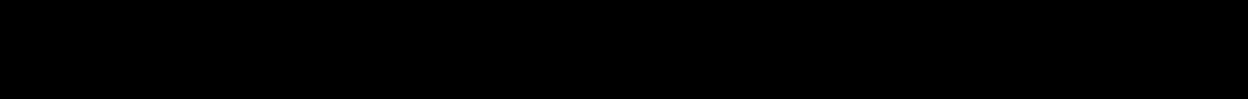
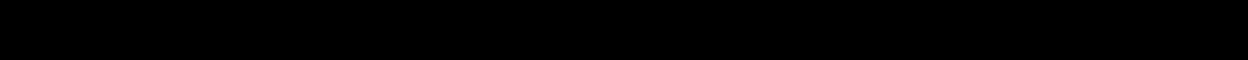
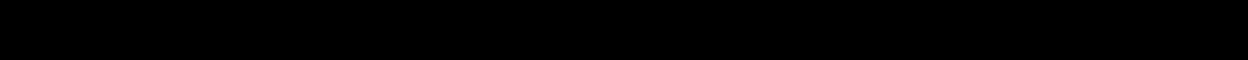
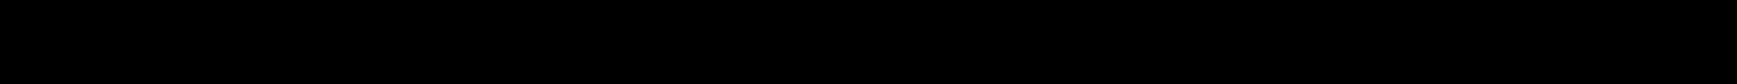
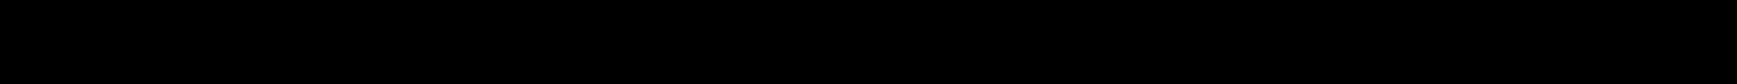
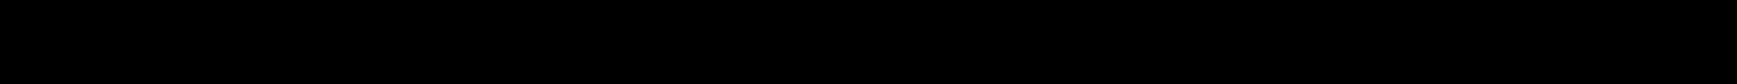

In [10]:
mosaic(
    dir_path='../data/FMGT', #raw data location
    format='fmgt', #raw data format
    mosaic_path='../scratch/Mosaic_200_fmgt.tif', #output mosaic
    crs='EPSG:32622', #coordinate reference system of raw data
    res=2 #output mosaic resolution
)

Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200_fmgt.tif


<img src="images/Mosaic_200_fmgt.png" style="height: 500px; width: auto;" />

<br>
We can also output the raw backscatter mosaic, without angular varying gain applied. We could choose to first output the bathymetric grid for use as a template to ensure the grids are aligned. These options are supported for all supported raw data formats.

In [11]:
#first mosaic the bathymetric grid
mosaic(
    dir_path='../data/FMGT', #raw data location
    format='fmgt', #raw data format
    layer='depth', #raw backscatter mosaic
    mosaic_path='../scratch/Mosaic_200_fmgt_bathy.tif', #output mosaic
    crs='EPSG:32622', #coordinate reference system of raw data
    res=2 #output mosaic resolution
)

#next use the bathymetric grid as a template for the raw backscatter mosaic
mosaic(
    dir_path='../data/FMGT', #raw data location
    format='fmgt', #raw data format
    layer='raw', #raw backscatter mosaic
    mosaic_path='../scratch/Mosaic_200_fmgt_raw.tif', #output mosaic
    template_path='../scratch/Mosaic_200_fmgt_bathy.tif' #coordinate reference system of raw data
)

Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200_fmgt_bathy.tif


Processing files:   0%|          | 0/10 [00:00<?, ?file/s]

Processing complete. Output mosaic saved as: ../scratch/Mosaic_200_fmgt_raw.tif


<img src="images/Mosaic_200_fmgt_bathy.png" style="height: 500px; width: auto;" />

<img src="images/Mosaic_200_fmgt_raw.png" style="height: 500px; width: auto;" />